In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [5]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'])

    return df

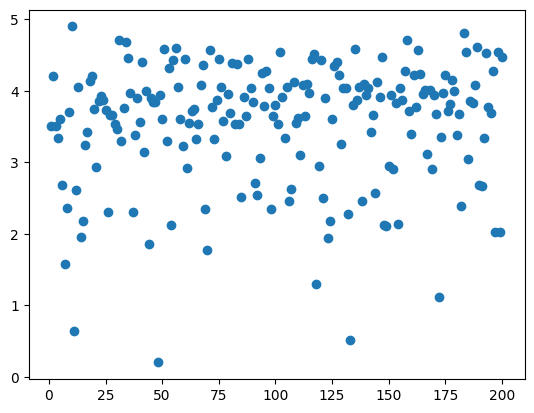

In [6]:
train_df= pd.read_csv("train.csv")
test_df= pd.read_csv('test.csv')

X_train= preprocess_data(train_df.drop(columns=['energy_output']))
y_train= np.log1p(train_df['energy_output'])

X_test= preprocess_data(test_df)

plt.scatter(train_df['SampleID'], y_train)
plt.show()

In [7]:
from catboost import CatBoostRegressor

model= CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    early_stopping_rounds=200,
    random_state= seed
)

model.fit(X_train, y_train, verbose=200)

0:	learn: 0.8330290	total: 47ms	remaining: 2m 20s
200:	learn: 0.0837482	total: 221ms	remaining: 3.08s
400:	learn: 0.0238441	total: 361ms	remaining: 2.35s
600:	learn: 0.0112942	total: 483ms	remaining: 1.93s
800:	learn: 0.0057795	total: 603ms	remaining: 1.66s
1000:	learn: 0.0031464	total: 711ms	remaining: 1.42s
1200:	learn: 0.0018095	total: 837ms	remaining: 1.25s
1400:	learn: 0.0011361	total: 948ms	remaining: 1.08s
1600:	learn: 0.0007156	total: 1.06s	remaining: 928ms
1800:	learn: 0.0004554	total: 1.19s	remaining: 795ms
2000:	learn: 0.0002836	total: 1.3s	remaining: 651ms
2200:	learn: 0.0001776	total: 1.42s	remaining: 516ms
2400:	learn: 0.0001073	total: 1.53s	remaining: 382ms
2600:	learn: 0.0000652	total: 1.64s	remaining: 252ms
2800:	learn: 0.0000413	total: 1.75s	remaining: 125ms
2999:	learn: 0.0000259	total: 1.87s	remaining: 0us


CatBoostRegressor(depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_state=42)

In [8]:
predictions= np.expm1(model.predict(X_test))

answer= pd.DataFrame({
    'SampleID': test_df['SampleID'],
    'energy_output': predictions
})

answer.head()

,SampleID,energy_output
0,1,55.282542
1,2,42.248774
2,3,48.620973
3,4,74.756013
4,5,87.386004


In [9]:
answer.to_csv("submission.csv", index= False)